<a href="https://colab.research.google.com/github/Miranita-ar/Skripsi-Gojek-App-Review/blob/main/Code/((C)(No%20CW)_Skripsi%20IndoBERT_(Eksperimen_3_no_class_weight).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ==========================================================
# 📌 1. INSTALL LIBRARY
# ==========================================================

Notebook ini digunakan untuk melakukan fine-tuning model
IndoBERT pada analisis sentimen.

Output yang dihasilkan:

- Model
- Tokenizer
- Evaluation Metrics
- Classification Report
- Confusion Matrix
- Learning Curve
- Summary Experiments

In [ ]:
# ==========================================================
# CELL 2 : INSTALL LIBRARY
# ==========================================================

!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00


In [ ]:
# ==========================================================
# CELL 3 : IMPORT LIBRARY
# ==========================================================

import os
import json
import time
import random
import warnings

import numpy as np
import pandas as pd

import torch

from google.colab import drive

from datasets import load_from_disk

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.metrics import (

    accuracy_score,

    precision_score,
    recall_score,
    f1_score,

    precision_recall_fscore_support,

    classification_report,

    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("="*60)
print("✅ Library berhasil diimport")
print("="*60)

✅ Library berhasil diimport


In [ ]:
# ==========================================================
# CELL : SET RANDOM SEED
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"Random Seed: {SEED}")

Random Seed: 42


# ==========================================================
# 📌 2. SETUP PROJECT
# ==========================================================

Tahap ini meliputi:

- Mount Google Drive
- Load Dataset
- Load Tokenizer
- Load Class Weight

In [ ]:
# ==========================================================
# CELL 5 : MOUNT GOOGLE DRIVE
# ==========================================================

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Skripsi_IndoBERT/No_Class_Weight"

print("="*60)
print("Project Directory")
print(PROJECT_DIR)
print("="*60)

Mounted at /content/drive
Project Directory
/content/drive/MyDrive/Skripsi_IndoBERT/No_Class_Weight


In [ ]:
# ==========================================================
# CELL 6 : LOAD DATASET
# ==========================================================

train_dataset = load_from_disk(
    f"{PROJECT_DIR}/data/tokenized/train_dataset_noCW"
)

valid_dataset = load_from_disk(
    f"{PROJECT_DIR}/data/tokenized/valid_dataset_noCW"
)

test_dataset = load_from_disk(
    f"{PROJECT_DIR}/data/tokenized/test_dataset_noCW"
)

print("="*60)
print("Jumlah Dataset")
print("="*60)

print(f"Train : {len(train_dataset):,}")
print(f"Valid : {len(valid_dataset):,}")
print(f"Test  : {len(test_dataset):,}")

Jumlah Dataset
Train : 15,835
Valid : 1,979
Test  : 1,980


In [ ]:
# ==========================================================
# CELL 7 : LOAD TOKENIZER & CLASS WEIGHT
# ==========================================================

tokenizer = AutoTokenizer.from_pretrained(
    f"{PROJECT_DIR}/data/tokenizer"
)

print("="*60)
print("Tokenizer Loaded")
print("="*60)

Tokenizer Loaded


In [ ]:
# ==========================================================
# CELL 8 : KONFIGURASI EKSPERIMEN
# ==========================================================

# =====================================================
# GANTI PARAMETER HANYA PADA BAGIAN INI
# =====================================================

EXPERIMENT_NAME = "Exp3_bs8_lr2e-5_ep4_noCW"

LEARNING_RATE = 2e-5
BATCH_SIZE = 8
NUM_EPOCHS = 4

# =====================================================
# FOLDER
# =====================================================

MODEL_DIR = (
    f"{PROJECT_DIR}/models/{EXPERIMENT_NAME}"
)

LOG_DIR = (
    f"{PROJECT_DIR}/logs/{EXPERIMENT_NAME}"
)

RESULT_DIR = (
    f"{PROJECT_DIR}/results/{EXPERIMENT_NAME}"
)

BEST_MODEL_DIR = (
    f"{MODEL_DIR}/best_model"
)

for folder in [

    MODEL_DIR,
    LOG_DIR,
    RESULT_DIR,
    BEST_MODEL_DIR

]:
    os.makedirs(folder, exist_ok=True)

print("="*60)
print("Konfigurasi Eksperimen")
print("="*60)

print(f"Experiment    : {EXPERIMENT_NAME}")
print(f"Learning Rate : {LEARNING_RATE}")
print(f"Batch Size    : {BATCH_SIZE}")
print(f"Epoch         : {NUM_EPOCHS}")

print("="*60)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"Device : {device}")

Konfigurasi Eksperimen
Experiment    : Exp3_bs8_lr2e-5_ep4_noCW
Learning Rate : 2e-05
Batch Size    : 8
Epoch         : 4
Device : cuda


# ==========================================================
# 📌 3. METRIK EVALUASI
# ==========================================================

Tahap ini mendefinisikan fungsi evaluasi yang akan digunakan
oleh Trainer selama proses training dan evaluasi.

Metric yang dihitung:

- Accuracy
- Precision (Macro, Micro, Weighted)
- Recall (Macro, Micro, Weighted)
- F1-Score (Macro, Micro, Weighted)
- Precision per kelas
- Recall per kelas
- F1 per kelas

In [ ]:
# ==========================================================
# CELL 10 : COMPUTE METRICS
# ==========================================================

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    # ======================================================
    # Accuracy
    # ======================================================

    accuracy = accuracy_score(
        labels,
        predictions
    )

    # ======================================================
    # Precision
    # ======================================================

    precision_per_class = precision_score(
        labels,
        predictions,
        average=None,
        zero_division=0
    )

    precision_macro = precision_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    precision_micro = precision_score(
        labels,
        predictions,
        average="micro",
        zero_division=0
    )

    precision_weighted = precision_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    # ======================================================
    # Recall
    # ======================================================

    recall_per_class = recall_score(
        labels,
        predictions,
        average=None,
        zero_division=0
    )

    recall_macro = recall_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    recall_micro = recall_score(
        labels,
        predictions,
        average="micro",
        zero_division=0
    )

    recall_weighted = recall_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    # ======================================================
    # F1 Score
    # ======================================================

    f1_per_class = f1_score(
        labels,
        predictions,
        average=None,
        zero_division=0
    )

    f1_macro = f1_score(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    f1_micro = f1_score(
        labels,
        predictions,
        average="micro",
        zero_division=0
    )

    f1_weighted = f1_score(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    # ======================================================
    # Return
    # ======================================================

    return {

        # Accuracy
        "accuracy": accuracy,

        # Precision
        "precision_macro": precision_macro,
        "precision_micro": precision_micro,
        "precision_weighted": precision_weighted,

        # Recall
        "recall_macro": recall_macro,
        "recall_micro": recall_micro,
        "recall_weighted": recall_weighted,

        # F1
        "macro_f1": f1_macro,
        "micro_f1": f1_micro,
        "weighted_f1": f1_weighted,

        # Per Class Precision
        "precision_negatif": precision_per_class[0],
        "precision_netral": precision_per_class[1],
        "precision_positif": precision_per_class[2],

        # Per Class Recall
        "recall_negatif": recall_per_class[0],
        "recall_netral": recall_per_class[1],
        "recall_positif": recall_per_class[2],

        # Per Class F1
        "f1_negatif": f1_per_class[0],
        "f1_netral": f1_per_class[1],
        "f1_positif": f1_per_class[2]
    }

# ==========================================================
# 📌 4. CUSTOM TRAINER
# ==========================================================

Trainer dimodifikasi agar menggunakan class weight
pada CrossEntropyLoss sehingga dapat menangani
ketidakseimbangan kelas (class imbalance).

In [ ]:
# ==========================================================
# CELL 12 : CUSTOM TRAINER
# ==========================================================

class CustomTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        **kwargs
    ):

        labels = inputs.get("labels")

        outputs = model(**inputs)

        logits = outputs.get("logits")

        loss_function = torch.nn.CrossEntropyLoss()

        loss = loss_function(

            logits.view(
                -1,
                model.config.num_labels
            ),

            labels.view(-1)
        )

        return (
            (loss, outputs)
            if return_outputs
            else loss
        )

# ==========================================================
# 📌 5. MEMUAT MODEL INDOBERT
# ==========================================================

Model yang digunakan adalah:

- indobenchmark/indobert-base-p2

Jumlah kelas:

- Negatif
- Netral
- Positif

In [ ]:
# ==========================================================
# CELL 14 : LOAD MODEL
# ==========================================================

model = AutoModelForSequenceClassification.from_pretrained(

    "indobenchmark/indobert-base-p2",

    num_labels=3

)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("="*60)
print("Model berhasil dimuat")
print("="*60)

print(f"Total Parameter      : {total_params:,}")
print(f"Trainable Parameter  : {trainable_params:,}")

print("="*60)

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model berhasil dimuat
Total Parameter      : 124,443,651
Trainable Parameter  : 124,443,651


In [ ]:
# ==========================================================
# CELL 16 : TRAINING ARGUMENTS
# ==========================================================

training_args = TrainingArguments(

    # ======================================================
    # OUTPUT
    # ======================================================
    output_dir=MODEL_DIR,
    logging_dir=LOG_DIR,

    # ======================================================
    # HYPERPARAMETER
    # ======================================================
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,

    weight_decay=0.01,

    # ======================================================
    # TRAIN / EVALUATION
    # ======================================================
    do_train=True,
    do_eval=True,

    eval_strategy="epoch",

    # Tidak menyimpan checkpoint
    save_strategy="no",

    # ======================================================
    # BEST MODEL
    # ======================================================
    load_best_model_at_end=False,

    # ======================================================
    # LOGGING
    # ======================================================
    logging_strategy="epoch",
    logging_steps=100,

    # ======================================================
    # RANDOM SEED
    # ======================================================
    seed=SEED,

    # ======================================================
    # REPORT
    # ======================================================
    report_to="none"

)

print("="*60)
print("✅ TrainingArguments berhasil dibuat")
print("="*60)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


✅ TrainingArguments berhasil dibuat


# ==========================================================
# 📌 7. MEMBUAT TRAINER
# ==========================================================

Trainer akan menggunakan:

- CustomTrainer
- Compute Metrics
- Early Stopping
- Class Weight

In [ ]:
# ==========================================================
# CELL 18 : TRAINER
# ==========================================================

trainer = CustomTrainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    processing_class=tokenizer,

    compute_metrics=compute_metrics

)

print("="*60)
print("✅ Trainer berhasil dibuat")
print("="*60)

✅ Trainer berhasil dibuat


# ==========================================================
# 📌 8. TRAINING MODEL
# ==========================================================

Melakukan proses fine-tuning IndoBERT.

Model terbaik dipilih berdasarkan
Weighted F1 Score.

In [ ]:
# ==========================================================
# CELL 20 : TRAINING MODEL
# ==========================================================

print("="*60)
print("🚀 Memulai Training...")
print("="*60)

start_time = time.time()

train_result = trainer.train()

training_time = time.time() - start_time

hours = int(training_time // 3600)
minutes = int((training_time % 3600) // 60)
seconds = int(training_time % 60)

print("="*60)
print("✅ Training selesai")
print("="*60)

print(f"Training Time : {hours:02d}:{minutes:02d}:{seconds:02d}")
print(f"Training Loss : {train_result.training_loss:.4f}")
print(f"Global Step   : {train_result.global_step}")

🚀 Memulai Training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Precision Micro,Precision Weighted,Recall Macro,Recall Micro,Recall Weighted,Macro F1,Micro F1,Weighted F1,Precision Negatif,Precision Netral,Precision Positif,Recall Negatif,Recall Netral,Recall Positif,F1 Negatif,F1 Netral,F1 Positif
1,0.353025,0.314259,0.906518,0.592469,0.906518,0.874243,0.625632,0.906518,0.906518,0.608192,0.906518,0.889582,0.831378,0.000000,0.946029,0.926471,0.000000,0.950426,0.876352,0.000000,0.948223
2,0.279895,0.337411,0.894896,0.673359,0.894896,0.884910,0.654383,0.894896,0.894896,0.658481,0.894896,0.889057,0.835637,0.238095,0.946345,0.888889,0.131579,0.942680,0.861441,0.169492,0.944509
3,0.218422,0.408957,0.895402,0.672832,0.895402,0.886661,0.655956,0.895402,0.895402,0.656157,0.895402,0.889155,0.818314,0.243243,0.956938,0.919935,0.118421,0.929512,0.866154,0.159292,0.943026
4,0.138489,0.516988,0.893380,0.678548,0.893380,0.894237,0.682789,0.893380,0.893380,0.680102,0.893380,0.893314,0.829528,0.242857,0.963259,0.890523,0.223684,0.934160,0.858944,0.232877,0.948486


✅ Training selesai
Training Time : 00:26:00
Training Loss : 0.2475
Global Step   : 7920


In [ ]:
# ==========================================================
# CELL 21 : SAVE MODEL
# ==========================================================

trainer.save_model(BEST_MODEL_DIR)

tokenizer.save_pretrained(BEST_MODEL_DIR)

print("="*60)
print("✅ Model terbaik berhasil disimpan")
print(BEST_MODEL_DIR)
print("="*60)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model terbaik berhasil disimpan
/content/drive/MyDrive/Skripsi_IndoBERT/No_Class_Weight/models/Exp3_bs8_lr2e-5_ep4_noCW/best_model


In [ ]:
# ==========================================================
# CELL 22 : SAVE TRAINING LOG
# ==========================================================

trainer_log = pd.DataFrame(
    trainer.state.log_history
)

trainer_log.to_csv(
    f"{RESULT_DIR}/trainer_log.csv",
    index=False
)

print("="*60)
print("✅ Trainer Log berhasil disimpan")
print("="*60)

display(trainer_log.head())

✅ Trainer Log berhasil disimpan


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_precision_micro,eval_precision_weighted,...,eval_f1_netral,eval_f1_positif,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.353025,0.336624,0.000015,1.0,1980,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,1980,0.314259,0.906518,0.592469,0.906518,0.874243,...,0.000000,0.948223,15.0707,131.314,16.456,NaN,NaN,NaN,NaN,NaN
2,0.279895,0.254100,0.000010,2.0,3960,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,3960,0.337411,0.894896,0.673359,0.894896,0.884910,...,0.169492,0.944509,15.0311,131.660,16.499,NaN,NaN,NaN,NaN,NaN
4,0.218422,0.153626,0.000005,3.0,5940,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# ==========================================================
# 📌 9. EVALUASI MODEL
# ==========================================================

Model dievaluasi menggunakan test dataset.

Output:

- Evaluation Metrics
- Classification Report
- Prediction
- Confusion Matrix

In [ ]:
# ==========================================================
# CELL 24 : EVALUASI TEST SET
# ==========================================================

print("=" * 60)
print("Evaluasi pada Test Dataset")
print("=" * 60)

test_result = trainer.evaluate(test_dataset)

print("\nHasil Evaluasi")

for key, value in test_result.items():

    if isinstance(value, float):
        print(f"{key:30s}: {value:.4f}")
    else:
        print(f"{key:30s}: {value}")

Evaluasi pada Test Dataset


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Precision Micro,Precision Weighted,Recall Macro,Recall Micro,Recall Weighted,Macro F1,Micro F1,Weighted F1,Precision Negatif,Precision Netral,Precision Positif,Recall Negatif,Recall Netral,Recall Positif,F1 Negatif,F1 Netral,F1 Positif
0.138489,0.510446,4,0.895960,0.635159,0.895960,0.890254,0.639126,0.895960,0.895960,0.636177,0.895960,0.892723,0.837672,0.107143,0.960661,0.892333,0.080000,0.945046,0.864139,0.091603,0.952790



Hasil Evaluasi
eval_loss                     : 0.5104
eval_accuracy                 : 0.8960
eval_precision_macro          : 0.6352
eval_precision_micro          : 0.8960
eval_precision_weighted       : 0.8903
eval_recall_macro             : 0.6391
eval_recall_micro             : 0.8960
eval_recall_weighted          : 0.8960
eval_macro_f1                 : 0.6362
eval_micro_f1                 : 0.8960
eval_weighted_f1              : 0.8927
eval_precision_negatif        : 0.8377
eval_precision_netral         : 0.1071
eval_precision_positif        : 0.9607
eval_recall_negatif           : 0.8923
eval_recall_netral            : 0.0800
eval_recall_positif           : 0.9450
eval_f1_negatif               : 0.8641
eval_f1_netral                : 0.0916
eval_f1_positif               : 0.9528


In [ ]:
# ==========================================================
# CELL 25 : PREDIKSI TEST SET
# ==========================================================

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

print("=" * 60)
print("Jumlah Data Test :", len(y_true))
print("=" * 60)

Jumlah Data Test : 1980


In [ ]:
# ==========================================================
# CELL 25 : PREDIKSI TEST SET
# ==========================================================

predictions = trainer.predict(test_dataset)

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

print("=" * 60)
print("Jumlah Data Test :", len(y_true))
print("=" * 60)

Jumlah Data Test : 1980


In [ ]:
# ==========================================================
# CELL 26 : CLASSIFICATION REPORT
# ==========================================================

report = classification_report(

    y_true,

    y_pred,

    target_names=[
        "Negatif",
        "Netral",
        "Positif"
    ],

    digits=4,

    output_dict=True

)

report_df = pd.DataFrame(report).transpose()

display(report_df.round(4))

,precision,recall,f1-score,support
Negatif,0.8377,0.8923,0.8641,613.000
Netral,0.1071,0.0800,0.0916,75.000
Positif,0.9607,0.9450,0.9528,1292.000
accuracy,0.8960,0.8960,0.8960,0.896
macro avg,0.6352,0.6391,0.6362,1980.000
weighted avg,0.8903,0.8960,0.8927,1980.000


In [ ]:
# ==========================================================
# CELL 27 : EVALUATION METRICS
# ==========================================================

metrics_summary = {

    "Accuracy": accuracy_score(
        y_true,
        y_pred
    ),

    "Precision Macro": precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    ),

    "Precision Micro": precision_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    ),

    "Precision Weighted": precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    ),

    "Recall Macro": recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    ),

    "Recall Micro": recall_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    ),

    "Recall Weighted": recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    ),

    "F1 Macro": f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    ),

    "F1 Micro": f1_score(
        y_true,
        y_pred,
        average="micro",
        zero_division=0
    ),

    "F1 Weighted": f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

}

metrics_df = pd.DataFrame(

    metrics_summary.items(),

    columns=[
        "Metric",
        "Value"
    ]

)

display(metrics_df)

,Metric,Value
0,Accuracy,0.895960
1,Precision Macro,0.635159
2,Precision Micro,0.895960
3,Precision Weighted,0.890254
4,Recall Macro,0.639126
5,Recall Micro,0.895960
6,Recall Weighted,0.895960
7,F1 Macro,0.636177
8,F1 Micro,0.895960
9,F1 Weighted,0.892723


In [ ]:
# ==========================================================
# CELL 28 : SAVE EVALUATION METRICS
# ==========================================================

metrics_df.to_csv(

    f"{RESULT_DIR}/evaluation_metrics.csv",

    index=False

)

with open(

    f"{RESULT_DIR}/metrics.json",

    "w"

) as f:

    json.dump(
        test_result,
        f,
        indent=4
    )

print("Evaluation Metrics berhasil disimpan")

Evaluation Metrics berhasil disimpan


In [ ]:
# ==========================================================
# CELL 29 : SAVE CLASSIFICATION REPORT
# ==========================================================

report_df.to_csv(

    f"{RESULT_DIR}/classification_report.csv"

)

print("Classification Report berhasil disimpan")

Classification Report berhasil disimpan


In [ ]:
# ==========================================================
# CELL 30 : SAVE PREDICTIONS
# ==========================================================

prediction_df = pd.DataFrame({

    "actual": y_true,

    "prediction": y_pred

})

prediction_df.to_csv(

    f"{RESULT_DIR}/predictions.csv",

    index=False

)

prediction_with_text_df = pd.DataFrame({

    "text": test_dataset["text"],

    "actual": y_true,

    "prediction": y_pred

})

prediction_with_text_df.to_csv(

    f"{RESULT_DIR}/predictions_with_text.csv",

    index=False

)

print("Predictions berhasil disimpan")

Predictions berhasil disimpan


# ==========================================================
# 📌 10. CONFUSION MATRIX
# ==========================================================

Visualisasi confusion matrix:

- Jumlah Prediksi
- Persentase Prediksi

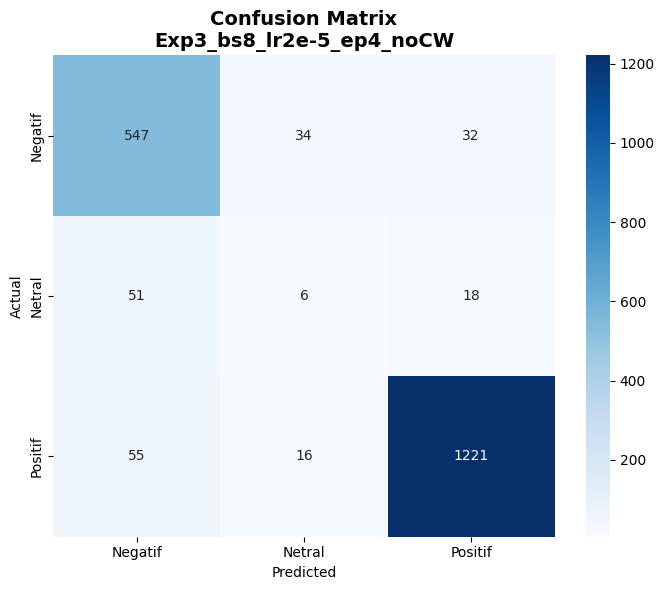

In [ ]:
# ==========================================================
# CELL 32 : CONFUSION MATRIX (COUNT)
# ==========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ],

    yticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ]

)

plt.title(
    f"Confusion Matrix\n{EXPERIMENT_NAME}",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(

    f"{RESULT_DIR}/confusion_matrix_count.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

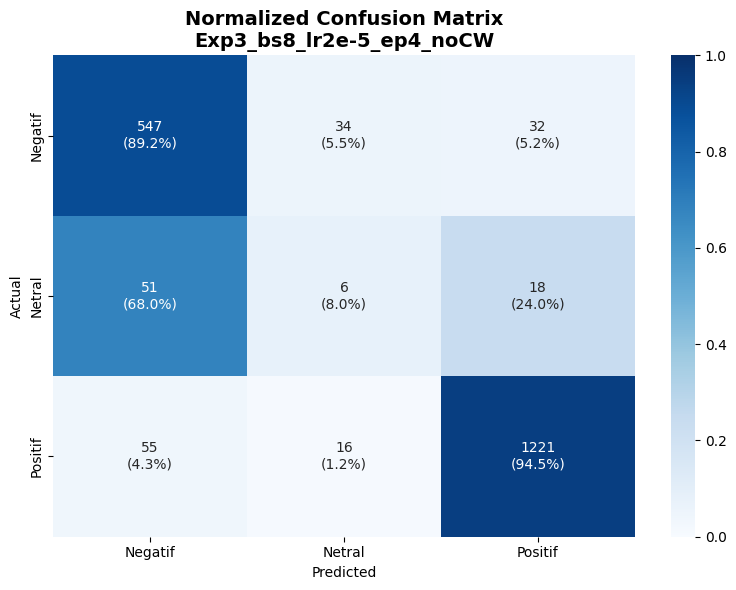

In [ ]:
# ==========================================================
# CELL 33 : CONFUSION MATRIX (PERCENTAGE)
# ==========================================================

cm_norm = cm.astype(float)

cm_norm = cm_norm / cm_norm.sum(axis=1)[:, np.newaxis]

labels = [

    [

        f"{v}\n({p:.1%})"

        for v, p in zip(r1, r2)

    ]

    for r1, r2 in zip(cm, cm_norm)

]

plt.figure(figsize=(8,6))

sns.heatmap(

    cm_norm,

    annot=np.asarray(labels),

    fmt="",

    cmap="Blues",

    vmin=0,

    vmax=1,

    xticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ],

    yticklabels=[
        "Negatif",
        "Netral",
        "Positif"
    ]

)

plt.title(

    f"Normalized Confusion Matrix\n{EXPERIMENT_NAME}",

    fontsize=14,

    fontweight="bold"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(

    f"{RESULT_DIR}/confusion_matrix_percentage.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# ==========================================================
# 📌 11. LEARNING CURVE
# ==========================================================

Visualisasi:

- Training Loss
- Validation Loss
- Validation F1

In [ ]:
# ==========================================================
# CELL 35 : EXTRACT TRAINING LOG
# ==========================================================

log_history = trainer.state.log_history

history_df = pd.DataFrame(log_history)

display(history_df.head())

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision_macro,eval_precision_micro,eval_precision_weighted,...,eval_f1_netral,eval_f1_positif,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.353025,0.336624,0.000015,1.0,1980,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,1980,0.314259,0.906518,0.592469,0.906518,0.874243,...,0.000000,0.948223,15.0707,131.314,16.456,NaN,NaN,NaN,NaN,NaN
2,0.279895,0.254100,0.000010,2.0,3960,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,3960,0.337411,0.894896,0.673359,0.894896,0.884910,...,0.169492,0.944509,15.0311,131.660,16.499,NaN,NaN,NaN,NaN,NaN
4,0.218422,0.153626,0.000005,3.0,5940,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ==========================================================
# CELL 36 : TRAINING HISTORY
# ==========================================================

# -----------------------------
# Training Log
# -----------------------------

train_log = (
    history_df[
        ["epoch", "loss"]
    ]
    .dropna(subset=["loss"])
    .drop_duplicates(subset=["epoch"], keep="last")
)

# -----------------------------
# Evaluation Log
# -----------------------------

eval_log = (
    history_df[
        [
            "epoch",
            "eval_loss",
            "eval_accuracy",
            "eval_precision_macro",
            "eval_precision_micro",
            "eval_precision_weighted",
            "eval_recall_macro",
            "eval_recall_micro",
            "eval_recall_weighted",
            "eval_macro_f1",
            "eval_micro_f1",
            "eval_weighted_f1",
        ]
    ]
    .dropna(subset=["eval_loss"])
    .drop_duplicates(subset=["epoch"], keep="last")
)

# -----------------------------
# Merge
# -----------------------------

history_summary = pd.merge(
    train_log,
    eval_log,
    on="epoch",
    how="inner"
)

history_summary = history_summary.sort_values("epoch")

history_summary.reset_index(
    drop=True,
    inplace=True
)

display(history_summary)

history_summary.to_csv(
    f"{RESULT_DIR}/training_history.csv",
    index=False
)

print("✅ Training history berhasil disimpan")

,epoch,loss,eval_loss,eval_accuracy,eval_precision_macro,eval_precision_micro,eval_precision_weighted,eval_recall_macro,eval_recall_micro,eval_recall_weighted,eval_macro_f1,eval_micro_f1,eval_weighted_f1
0,1.0,0.353025,0.314259,0.906518,0.592469,0.906518,0.874243,0.625632,0.906518,0.906518,0.608192,0.906518,0.889582
1,2.0,0.279895,0.337411,0.894896,0.673359,0.894896,0.884910,0.654383,0.894896,0.894896,0.658481,0.894896,0.889057
2,3.0,0.218422,0.408957,0.895402,0.672832,0.895402,0.886661,0.655956,0.895402,0.895402,0.656157,0.895402,0.889155
3,4.0,0.138489,0.510446,0.895960,0.635159,0.895960,0.890254,0.639126,0.895960,0.895960,0.636177,0.895960,0.892723


✅ Training history berhasil disimpan


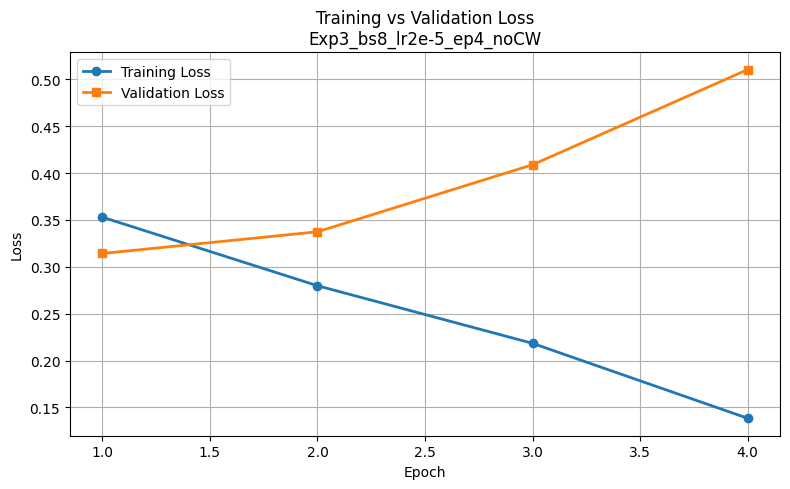

In [ ]:
# ==========================================================
# CELL 37 : LOSS CURVE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(

    history_summary["epoch"],

    history_summary["loss"],

    marker="o",

    linewidth=2,

    label="Training Loss"

)

plt.plot(

    history_summary["epoch"],

    history_summary["eval_loss"],

    marker="s",

    linewidth=2,

    label="Validation Loss"

)

plt.grid(True)

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(

    f"Training vs Validation Loss\n{EXPERIMENT_NAME}"

)

plt.tight_layout()

plt.savefig(

    f"{RESULT_DIR}/loss_curve.png",

    dpi=300

)

plt.show()

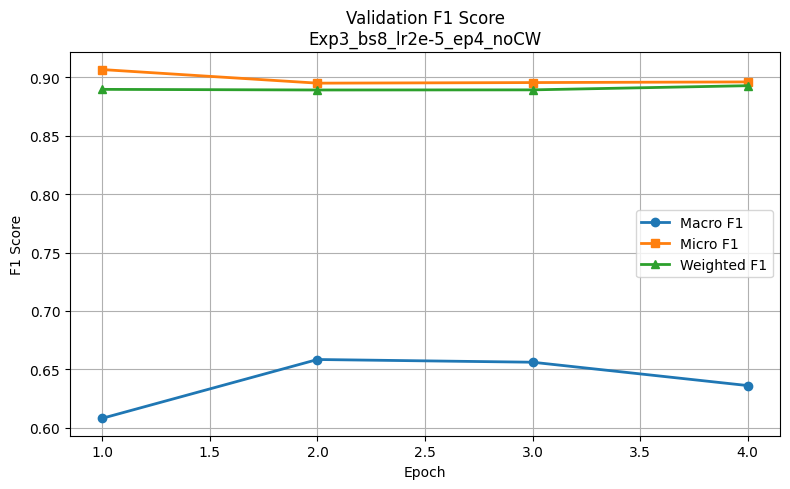

In [ ]:
# ==========================================================
# CELL 38 : F1 CURVE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(

    history_summary["epoch"],

    history_summary["eval_macro_f1"],

    marker="o",

    linewidth=2,

    label="Macro F1"

)

plt.plot(

    history_summary["epoch"],

    history_summary["eval_micro_f1"],

    marker="s",

    linewidth=2,

    label="Micro F1"

)

plt.plot(

    history_summary["epoch"],

    history_summary["eval_weighted_f1"],

    marker="^",

    linewidth=2,

    label="Weighted F1"

)

plt.grid(True)

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("F1 Score")

plt.title(

    f"Validation F1 Score\n{EXPERIMENT_NAME}"

)

plt.tight_layout()

plt.savefig(

    f"{RESULT_DIR}/f1_curve.png",

    dpi=300

)

plt.show()

In [ ]:
best_epoch = history_summary.loc[
    history_summary["eval_weighted_f1"].idxmax()
]

print("=" * 60)
print("🏆 Best Epoch")
print("=" * 60)
print(best_epoch)

🏆 Best Epoch
epoch                      4.000000
loss                       0.138489
eval_loss                  0.510446
eval_accuracy              0.895960
eval_precision_macro       0.635159
eval_precision_micro       0.895960
eval_precision_weighted    0.890254
eval_recall_macro          0.639126
eval_recall_micro          0.895960
eval_recall_weighted       0.895960
eval_macro_f1              0.636177
eval_micro_f1              0.895960
eval_weighted_f1           0.892723
Name: 3, dtype: float64


In [ ]:
# ==========================================================
# CELL 36B : BEST EPOCH
# ==========================================================

best_epoch = history_summary.loc[
    history_summary["eval_weighted_f1"].idxmax()
]

best_epoch_df = pd.DataFrame(best_epoch).T

print("=" * 60)
print("🏆 BEST EPOCH")
print("=" * 60)

display(best_epoch_df.round(4))

best_epoch_df.to_csv(
    f"{RESULT_DIR}/best_epoch.csv",
    index=False
)

print("✅ Best epoch berhasil disimpan")

🏆 BEST EPOCH


,epoch,loss,eval_loss,eval_accuracy,eval_precision_macro,eval_precision_micro,eval_precision_weighted,eval_recall_macro,eval_recall_micro,eval_recall_weighted,eval_macro_f1,eval_micro_f1,eval_weighted_f1
3,4.0,0.1385,0.5104,0.896,0.6352,0.896,0.8903,0.6391,0.896,0.896,0.6362,0.896,0.8927


✅ Best epoch berhasil disimpan


# ==========================================================
# 📌 12. UPDATE SUMMARY EKSPERIMEN
# ==========================================================

Seluruh hasil utama eksperimen disimpan ke dalam file
summary_experiments.csv sehingga memudahkan
perbandingan antar konfigurasi hyperparameter.

In [ ]:
# ==========================================================
# CELL 40 : UPDATE SUMMARY EXPERIMENTS
# ==========================================================

summary_file = f"{PROJECT_DIR}/results/summary_experiments.csv"

summary_row = pd.DataFrame([{

    "experiment": EXPERIMENT_NAME,

    "learning_rate": LEARNING_RATE,

    "batch_size": BATCH_SIZE,

    "epochs": NUM_EPOCHS,

    "training_time_seconds": round(training_time,2),

    "best_epoch": int(best_epoch["epoch"]),

    # Loss

    "train_loss": best_epoch["loss"],

    "eval_loss": best_epoch["eval_loss"],

    # Accuracy

    "accuracy": best_epoch["eval_accuracy"],

    # Precision

    "precision_macro": best_epoch["eval_precision_macro"],
    "precision_micro": best_epoch["eval_precision_micro"],
    "precision_weighted": best_epoch["eval_precision_weighted"],

    # Recall

    "recall_macro": best_epoch["eval_recall_macro"],
    "recall_micro": best_epoch["eval_recall_micro"],
    "recall_weighted": best_epoch["eval_recall_weighted"],

    # F1

    "macro_f1": best_epoch["eval_macro_f1"],
    "micro_f1": best_epoch["eval_micro_f1"],
    "weighted_f1": best_epoch["eval_weighted_f1"]

}])

if os.path.exists(summary_file):

    old_summary = pd.read_csv(summary_file)

    old_summary = old_summary[
        old_summary["experiment"] != EXPERIMENT_NAME
    ]

    summary_df = pd.concat(
        [old_summary, summary_row],
        ignore_index=True
    )

else:

    summary_df = summary_row

summary_df = summary_df.sort_values(
    "weighted_f1",
    ascending=False
)

summary_df.to_csv(
    summary_file,
    index=False
)

print("="*60)
print("Summary Experiments berhasil diperbarui")
print("="*60)

display(summary_df)

Summary Experiments berhasil diperbarui


,experiment,learning_rate,batch_size,epochs,training_time_seconds,best_epoch,train_loss,eval_loss,accuracy,precision_macro,precision_micro,precision_weighted,recall_macro,recall_micro,recall_weighted,macro_f1,micro_f1,weighted_f1
0,Exp1_bs8_lr2e-5_ep3_noCW,0.00002,8,3,1231.15,3,0.200115,0.381596,0.909596,0.696015,0.909596,0.896443,0.655994,0.909596,0.909596,0.658222,0.909596,0.900375
1,Exp3_bs8_lr2e-5_ep4_noCW,0.00002,8,4,1560.25,4,0.138489,0.510446,0.895960,0.635159,0.895960,0.890254,0.639126,0.895960,0.895960,0.636177,0.895960,0.892723


In [ ]:
# ==========================================================
# CELL 41 : FINAL SUMMARY
# ==========================================================

print("\n" + "="*70)

print(f"EKSPERIMEN : {EXPERIMENT_NAME}")

print("="*70)

print(f"Learning Rate  : {LEARNING_RATE}")

print(f"Batch Size     : {BATCH_SIZE}")

print(f"Epoch          : {NUM_EPOCHS}")

print("-"*70)

print(f"Accuracy       : {best_epoch['eval_accuracy']:.4f}")

print(f"Macro F1       : {best_epoch['eval_macro_f1']:.4f}")

print(f"Micro F1       : {best_epoch['eval_micro_f1']:.4f}")

print(f"Weighted F1    : {best_epoch['eval_weighted_f1']:.4f}")

print("-"*70)

print(f"Training Time  : {training_time:.2f} detik")

print("="*70)

print("Folder Hasil")

print(RESULT_DIR)

print("="*70)


EKSPERIMEN : Exp3_bs8_lr2e-5_ep4_noCW
Learning Rate  : 2e-05
Batch Size     : 8
Epoch          : 4
----------------------------------------------------------------------
Accuracy       : 0.8960
Macro F1       : 0.6362
Micro F1       : 0.8960
Weighted F1    : 0.8927
----------------------------------------------------------------------
Training Time  : 1560.25 detik
Folder Hasil
/content/drive/MyDrive/Skripsi_IndoBERT/No_Class_Weight/results/Exp3_bs8_lr2e-5_ep4_noCW
